In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Libraries**

In [2]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data
# Option 1: classic Keras
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import load_img, img_to_array



# Loading **Dataset**

In [5]:
from sklearn.utils import shuffle
import os
train_dir = '/content/drive/MyDrive/braintumor/Training'
test_dir = '/content/drive/MyDrive/braintumor/Testing'
train_paths = []
train_labels = []

class_names = sorted(os.listdir(train_dir))   # 🔥 FIXED ORDER
for label in class_names:
    label_folder = os.path.join(train_dir, label)
    for image in os.listdir(label_folder):
        train_paths.append(os.path.join(label_folder, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

test_paths = []
test_labels = []

for label in class_names:   # USE SAME CLASS ORDER
    label_folder = os.path.join(test_dir, label)
    for image in os.listdir(label_folder):
        test_paths.append(os.path.join(label_folder, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)
label_map = {name: i for i, name in enumerate(class_names)}
inverse_label_map = {i: name for name, i in label_map.items()}

# Data **Visualization**

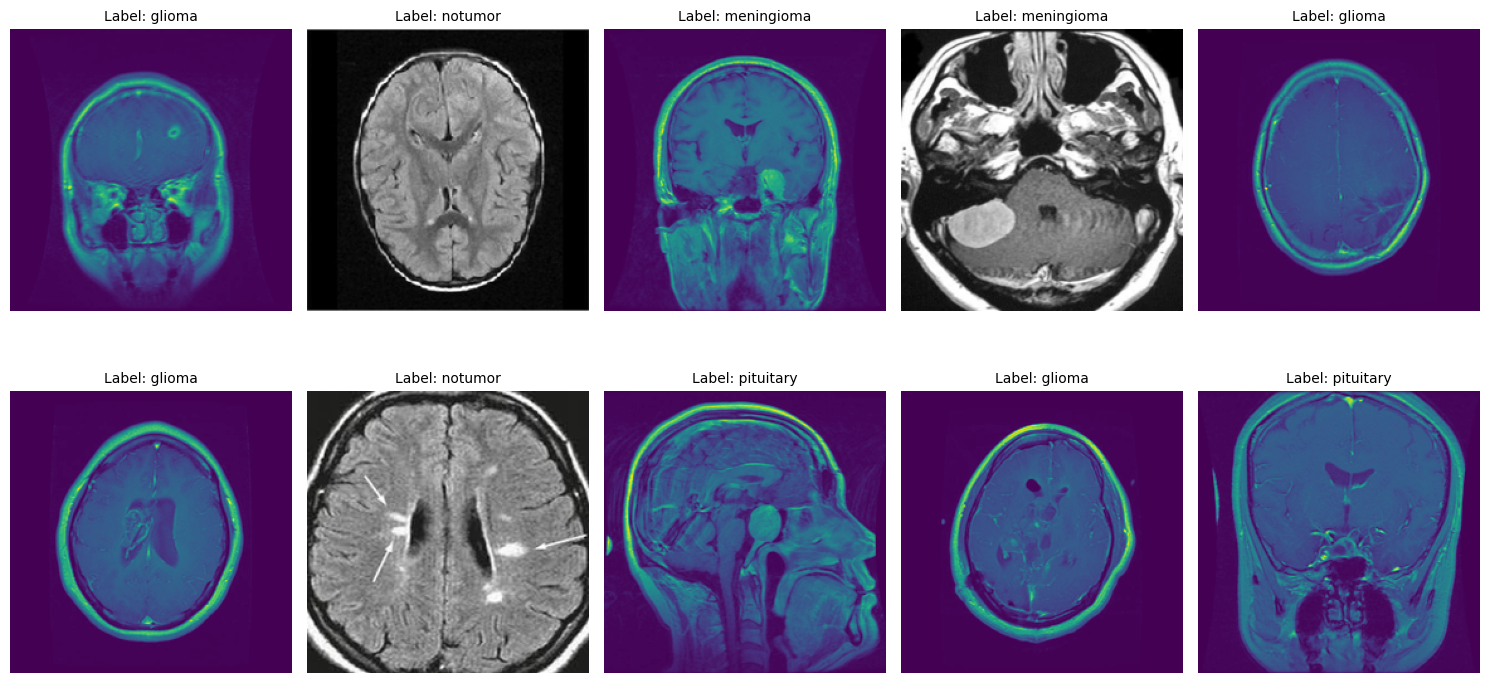

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

# Helper **Functions**

In [7]:
# Image Augmentation function
def augment_image(image):
    # image is a PIL image from load_img
    image = np.array(image)                     # to NumPy
    image = Image.fromarray(np.uint8(image))    # back to PIL for enhancement

    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))    # Random contrast

    image = np.array(image) / 255.0            # Normalize pixel values to [0, 1]
    return image


# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images, dtype=np.float32)


# Encoding labels (convert label names to integers)
# Uses the global label_map you already created from class_names
def encode_label(labels):
    return np.array([label_map[label] for label in labels], dtype=np.int32)


# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        # Optional: shuffle each epoch
        p, l = shuffle(paths, labels, random_state=42)
        for i in range(0, len(p), batch_size):
            batch_paths = p[i:i + batch_size]
            batch_labels = l[i:i + batch_size]

            batch_images = open_images(batch_paths)      # Open and augment images
            batch_labels_enc = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels_enc          # Yield the batch


# **Model**

* The model is developed using Transfer Learning with the pre-trained VGG16 convolutional neural network.

* The input image size is standardized to 128 × 128 × 3 (RGB).

* The VGG16 model is loaded with:
    Pre-trained ImageNet weights
    include_top=False to remove the original classification layers.

* All layers of the VGG16 base model are initially frozen to preserve pre-trained feature extraction capabilities.

* The last four convolutional layers are unfrozen to enable fine-tuning for better adaptation to the custom dataset.

* A Sequential model is created to stack additional layers on top of the base model.

* The VGG16 base model acts as a feature extractor, generating high-level feature maps from input images.

* A Flatten layer is added to convert 3D feature maps into a 1D feature vector.

* A Dropout layer (30%) is added to reduce overfitting.

* A Fully Connected Dense layer with 128 neurons and ReLU activation is added to learn dataset-specific patterns.

* Another Dropout layer (20%) is added for further regularization.

* The final Dense output layer uses Softmax activation to classify images into multiple categories.

* The model is compiled using:
    Adam optimizer with learning rate 0.0001
    Sparse Categorical Crossentropy loss function
    Accuracy metric

* The model is trained with:
    Batch size of 20
    5 training epochs
    Steps per epoch calculated using dataset size

* The architecture effectively combines pre-trained feature extraction with custom classification layers for improved performance and reduced training time.

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMAGE_SIZE = 128

# Base model
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Functional API
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs)
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Train
history = model.fit(
    datagen(train_paths, train_labels, batch_size=20, epochs=5),
    epochs=5,
    steps_per_epoch=len(train_paths) // 20
)

# Save properly
model.save("final_model.keras")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 1607s 6s/step - loss: 0.6810 - sparse_categorical_accuracy: 0.7325
Epoch 2/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 1428s 5s/step - loss: 0.2411 - sparse_categorical_accuracy: 0.9175
Epoch 3/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 1430s 5s/step - loss: 0.1554 - sparse_categorical_accuracy: 0.9423
Epoch 4/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 1429s 5s/step - loss: 0.1100 - sparse_categorical_accuracy: 0.9605
Epoch 5/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 1427s 5s/step - loss: 0.0890 - sparse_categorical_accuracy: 0.9686


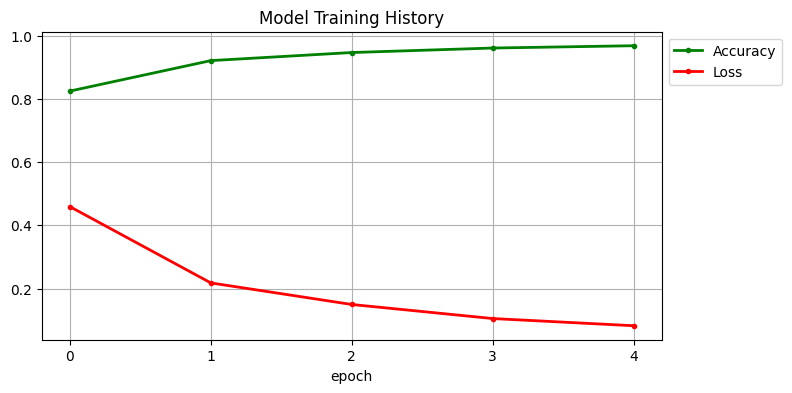

In [11]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(5)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


Report of the model

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

42/42 ━━━━━━━━━━━━━━━━━━━━ 279s 7s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       300
           1       0.90      0.94      0.92       306
           2       0.98      1.00      0.99       421
           3       0.99      0.99      0.99       300

    accuracy                           0.96      1327
   macro avg       0.96      0.95      0.96      1327
weighted avg       0.96      0.96      0.96      1327



Confussion Matrix

Confusion Matrix:
[[266  30   4   0]
 [ 10 289   4   3]
 [  0   0 421   0]
 [  1   3   0 296]]


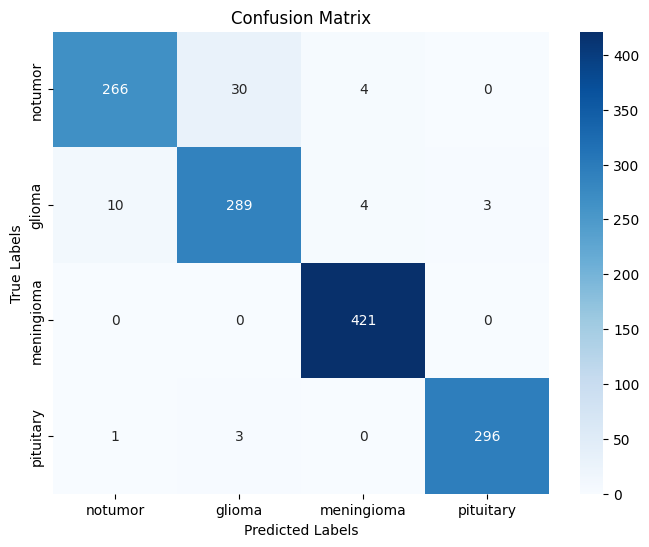

In [14]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Roc Curve

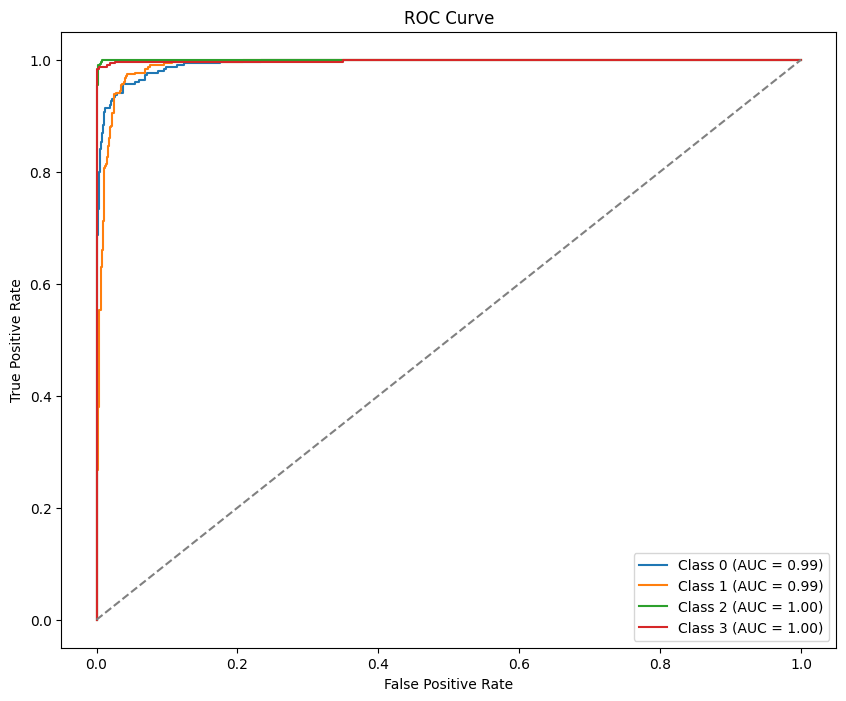

In [15]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [16]:
from tensorflow.keras.models import load_model
model.save("model.h5")


In [17]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

Model prediction

In [18]:
# Use the same order you used for training
# class_names = sorted(os.listdir(train_dir))
# label_map = {name: i for i, name in enumerate(class_names)}
# inverse_label_map = {i: name for name, i in label_map.items()}

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = int(np.argmax(predictions, axis=1)[0])
        confidence_score = float(np.max(predictions, axis=1)[0])

        # Use inverse_label_map to get the true class name
        predicted_label = inverse_label_map[predicted_class_index]

        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()
    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


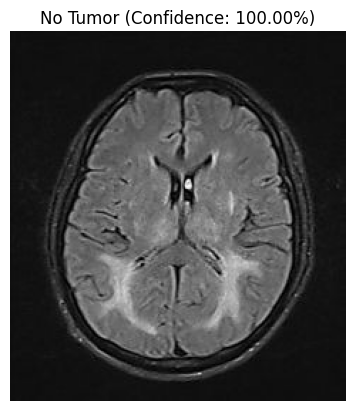

In [19]:
# Example usage
image_path = '/content/drive/MyDrive/braintumor/Testing/notumor/Te-noTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


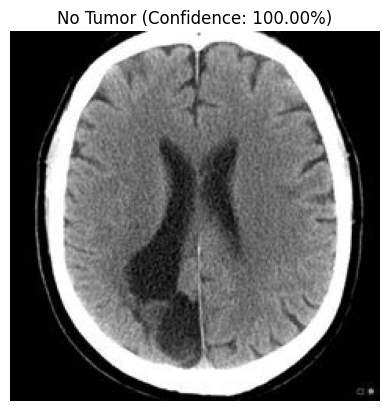

In [20]:
# Example usage
image_path = '/content/drive/MyDrive/braintumor/Testing/notumor/Te-noTr_0009.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


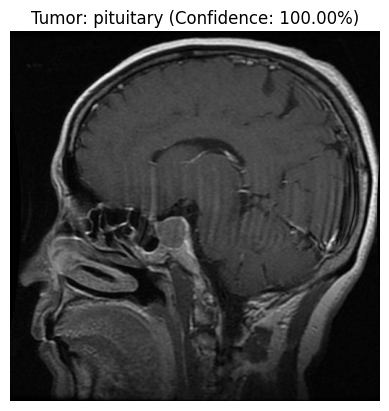

In [21]:
# Example usage
image_path = '/content/drive/MyDrive/braintumor/Testing/pituitary/Te-piTr_0007.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


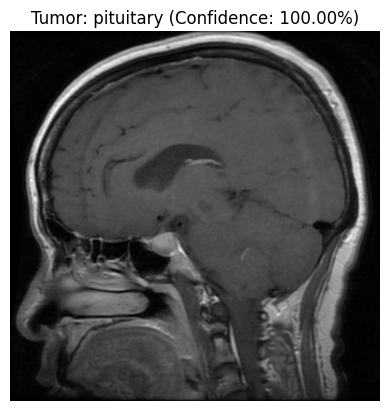

In [22]:
image_path = '/content/drive/MyDrive/braintumor/Testing/pituitary/Te-piTr_0003.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


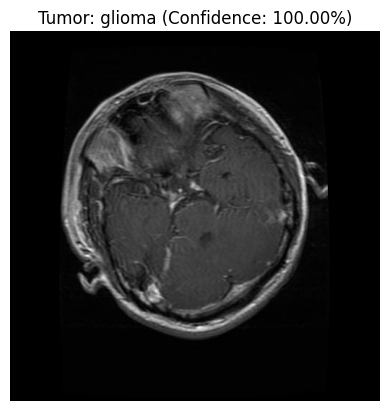

In [23]:
image_path='/content/drive/MyDrive/braintumor/Testing/glioma/Te-glTr_0006.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


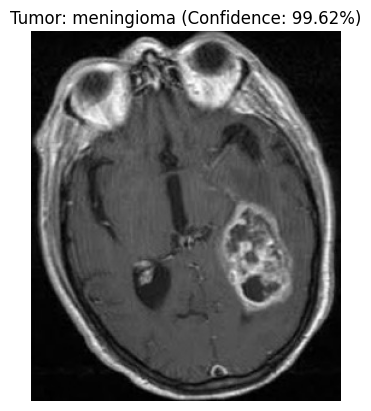

In [24]:
image_path='/content/drive/MyDrive/braintumor/Testing/meningioma/Te-meTr_0001.jpg'
detect_and_display(image_path,model)